# Solution: Univariate Analysis — Palmer Penguins

**Exercises from notebook `02_univariate_analysis.ipynb`**

Jingxu Li - 320230942071


## Exercise 1: Spread, and Where It Hides

Compute the **mean, median, and standard deviation** of `bill_length_mm` overall. Now compute the same three numbers **within each species**. Compare the overall std to the per-species stds — why does the spread *shrink* inside groups, and how does that preview the lesson of Notebook 3?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../dataset/penguins.csv')
print('Setup complete. Shape:', df.shape)
df.head()

Setup complete. Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
# Overall statistics
overall_mean = df['bill_length_mm'].mean()
overall_median = df['bill_length_mm'].median()
overall_std = df['bill_length_mm'].std()
print(f'Overall — Mean: {overall_mean:.2f}, Median: {overall_median:.2f}, Std: {overall_std:.2f}')

# Per-species statistics
by_species = df.groupby('species')['bill_length_mm'].agg(['mean', 'median', 'std'])
print(by_species.round(2))

Overall — Mean: 43.92, Median: 44.45, Std: 5.46
            mean  median   std
species                       
Adelie     38.79   38.80  2.66
Chinstrap  48.83   49.55  3.34
Gentoo     47.50   47.30  3.08


**Answer:**

The overall standard deviation is 5.46, while the standard deviations for each species are much smaller: 2.66 for Adelie penguins, 3.34 for Gentoo penguins, and 3.08 for Emperor penguins. Since the overall data includes three completely different species, and their typical beak lengths are all different (about 38.8 mm for Adelie penguins, about 49.8 mm for Gentoo penguins, and about 47.5 mm for Emperor penguins), the differences within each group will be reduced. While the differences between different species will increase the overall variance. This indicates the core point of the third notebook: species is a potential variable - ignoring it will make the data appear as a chaotic and highly variable single group, but in fact it contains three separate clusters that are mutually isolated.


## Exercise 2: Histogram of Body Mass

Make a histogram of `body_mass_g`. Is it roughly symmetric or skewed? Back your answer by comparing the **mean and median**, and say which one you'd report as the "typical" penguin and why.


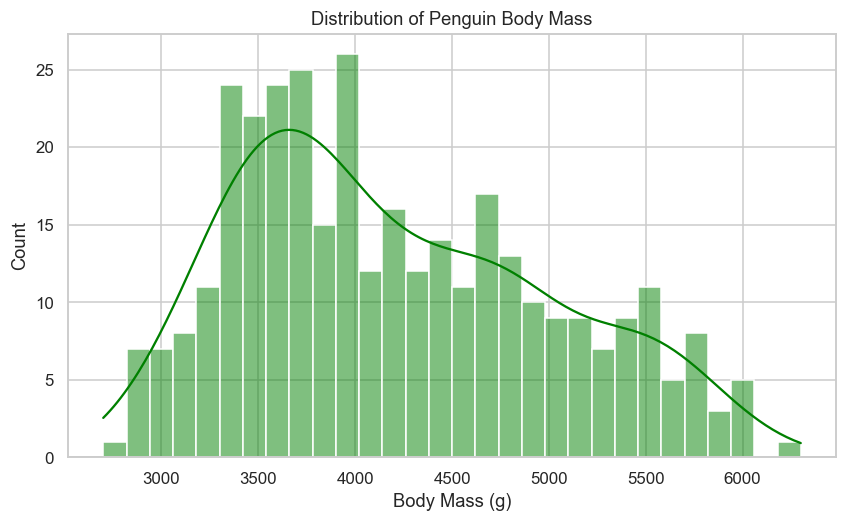

Mean: 4201.8 g, Median: 4050.0 g
Mean − Median = 151.8 g
Skewness: 0.470


In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(df['body_mass_g'].dropna(), bins=30, kde=True, color='green')
plt.title('Distribution of Penguin Body Mass')
plt.xlabel('Body Mass (g)')
plt.ylabel('Count')
plt.show()

mean_mass = df['body_mass_g'].mean()
median_mass = df['body_mass_g'].median()
print(f'Mean: {mean_mass:.1f} g, Median: {median_mass:.1f} g')
print(f'Mean − Median = {mean_mass - median_mass:.1f} g')
print(f'Skewness: {df["body_mass_g"].skew():.3f}')

**Answer:**

The histogram shows a **right-skewed** (positively skewed) trend: there is a longer tail extending toward higher body masses. The mean (4201.8 g) is larger than the median (4050.0 g), which confirms right skew. I would report the **median (4050 g)** as the "typical" penguin body mass because the median is robust to skewness and the influence of the heavier Gentoo penguins, providing a better one-number summary of the centre for this non-symmetric distribution.


## Exercise 3: When the Outlier Rule Stays Silent

Make a box plot of `flipper_length_mm` and run `find_outliers` on it. It flags about *zero* points, yet you know this column is bimodal. Explain the apparent contradiction: why doesn't the 1.5×IQR rule treat the two humps as outliers? What's the lesson about what outlier rules *cannot* catch?


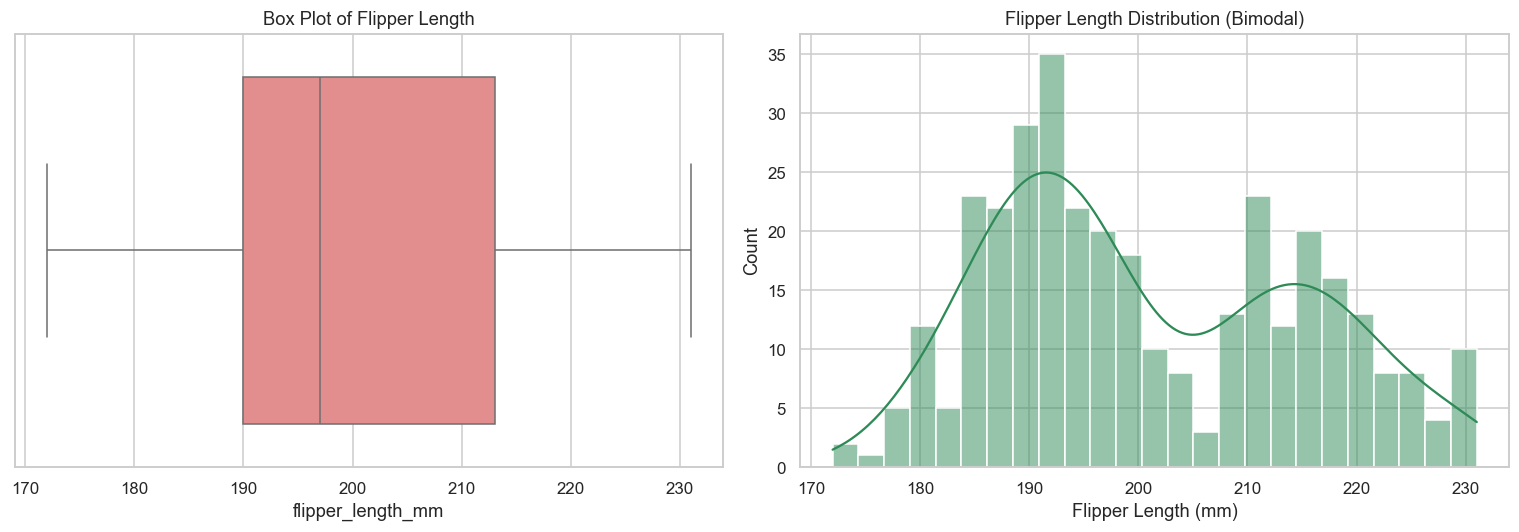

Number of outliers (1.5×IQR rule): 0
IQR: 23.0 mm


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(x=df['flipper_length_mm'], ax=axes[0], color='lightcoral')
axes[0].set_title('Box Plot of Flipper Length')

# Histogram
sns.histplot(df['flipper_length_mm'].dropna(), bins=25, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Flipper Length Distribution (Bimodal)')
axes[1].set_xlabel('Flipper Length (mm)')
plt.tight_layout()
plt.show()

def find_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < low) | (s > high)]

outliers = find_outliers(df['flipper_length_mm'])
print(f'Number of outliers (1.5×IQR rule): {len(outliers)}')
print(f'IQR: {df["flipper_length_mm"].quantile(0.75) - df["flipper_length_mm"].quantile(0.25):.1f} mm')

**Answer:**

The 1.5*IQR rule would classify zero values as outliers because both peaks of the bimodal distribution are within the boundaries based on the overall interquartile range. This rule can only detect points that are far from the data points in a single distribution - it cannot distinguish between a single group and a mixture of two or more different groups. 
<p>The outlier rules cannot detect multimodal or hidden group structures. They can only identify extreme individual points, but cannot indicate the existence of independent clusters in the data. That's why histograms and visual inspections are still very important.


## Exercise 4: Bar Chart of Islands

Make a bar chart of `island` and report the proportion of penguins on each. Which island hosts the most penguins?


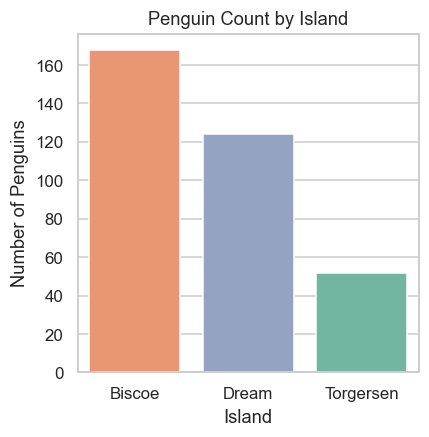

Proportion of penguins on each island:
island
Biscoe       0.488
Dream        0.360
Torgersen    0.151
Name: proportion, dtype: float64

Biscoe hosts the most penguins: Biscoe (48.8%)


In [28]:
plt.figure(figsize=(4, 4))
order = df['island'].value_counts().index
sns.countplot(data=df, x='island', order=order, 
              hue='island', palette='Set2', legend=False)
plt.title('Penguin Count by Island')
plt.xlabel('Island')
plt.ylabel('Number of Penguins')
plt.show()


props = df['island'].value_counts(normalize=True).round(3)
print('Proportion of penguins on each island:')
print(props)
print(f'\nBiscoe hosts the most penguins: {props.idxmax()} ({props.max():.1%})')

**Answer:**

Biscoe island hosts the most penguins (48.8%), followed by Dream (36.0%), and Torgersen (15.1%).


## Exercise 5: Relative Spread — Coefficient of Variation

For each numeric column compute the *coefficient of variation* (CV = std / mean). Which measurement varies the most relative to its size — and why is CV a fairer comparison than comparing raw standard deviations?


In [29]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

print('Coefficient of Variation (CV = std / mean):')
print('-' * 45)
for col in numeric_cols:
    mu = df[col].mean()
    sigma = df[col].std()
    cv = sigma / mu
    print(f'{col:22s}: σ = {sigma:7.2f}, μ = {mu:7.2f}, CV = {cv:.4f}')

print('\nBody mass has the largest CV, meaning it varies most relative to its scale.')

Coefficient of Variation (CV = std / mean):
---------------------------------------------
bill_length_mm        : σ =    5.46, μ =   43.92, CV = 0.1243
bill_depth_mm         : σ =    1.97, μ =   17.15, CV = 0.1151
flipper_length_mm     : σ =   14.06, μ =  200.92, CV = 0.0700
body_mass_g           : σ =  801.95, μ = 4201.75, CV = 0.1909

Body mass has the largest CV, meaning it varies most relative to its scale.


**Answer:**

Body mass exhibits the greatest relative variability, with a CV of roughly 0.191, whereas flipper length is the most consistent at about 0.070. CV is more equitable than raw standard deviation because it scales spread by the mean, neutralizing differences in units and magnitude—an SD of 800 g for a 4,000 g body mass and 5.5 mm for a 44 mm bill length cannot be directly compared without such normalization.


## Exercise 6: Challenge — Flipper Length Histogram Coloured by Species

Re-draw the flipper-length histogram, split by species with `sns.histplot()`. Do the two humps line up with the species? Write one sentence on what the colours reveal.


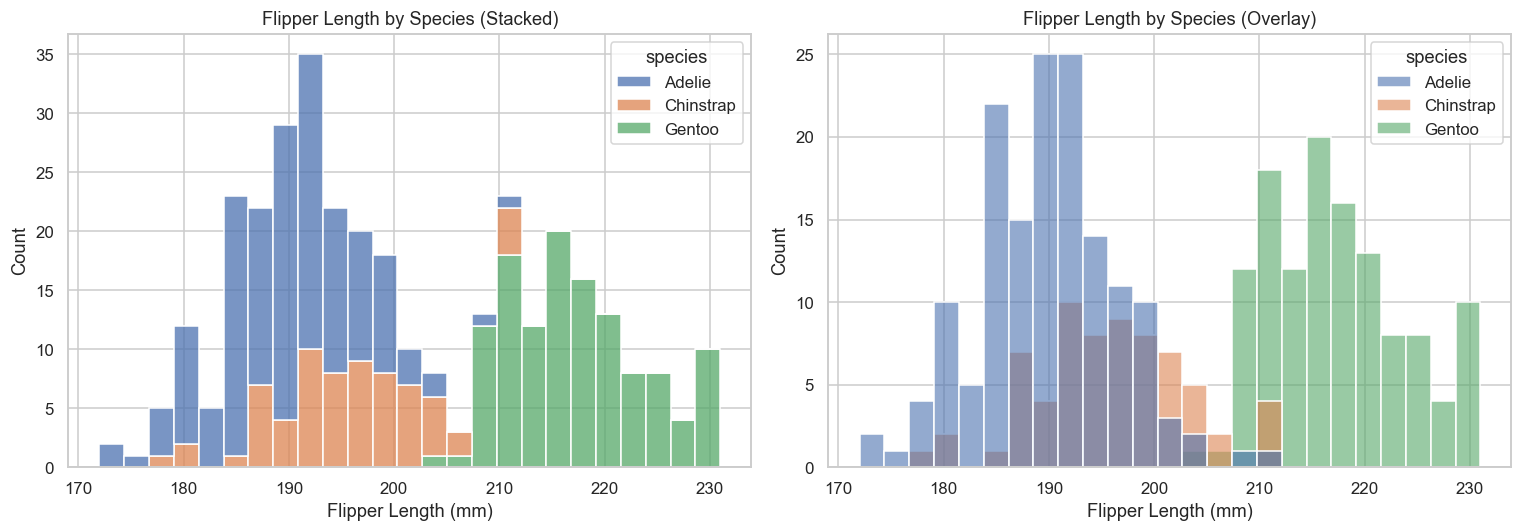

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked histogram
sns.histplot(data=df, x='flipper_length_mm', hue='species', bins=25, multiple='stack', ax=axes[0])
axes[0].set_title('Flipper Length by Species (Stacked)')
axes[0].set_xlabel('Flipper Length (mm)')

# Overlaid histogram
sns.histplot(data=df, x='flipper_length_mm', hue='species', bins=25, alpha=0.6, ax=axes[1])
axes[1].set_title('Flipper Length by Species (Overlay)')
axes[1].set_xlabel('Flipper Length (mm)')
plt.tight_layout()
plt.show()

**Answer:**

Yes, the two humps line up precisely with species, and the colours reveal that the apparent bimodality is merely the signature of two distinct species groups—shorter-flippered Adelie and Chinstrap penguins on the left and longer-flippered Gentoo penguins on the right.
